In [21]:
from transformers import pipeline
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [22]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [24]:
df['review'][10]

'Phil the Alien is one of those quirky films where the humour is based around the oddness of everything rather than actual punchlines.<br /><br />At first it was very odd and pretty funny but as the movie progressed I didn\'t find the jokes or oddness funny anymore.<br /><br />Its a low budget film (thats never a problem in itself), there were some pretty interesting characters, but eventually I just lost interest.<br /><br />I imagine this film would appeal to a stoner who is currently partaking.<br /><br />For something similar but better try "Brother from another planet"'

In [25]:
X_test = df['review'].iloc[:10000]  
y_test = df['sentiment'].iloc[:10000]

In [26]:
hf_model = pipeline("sentiment-analysis")

hf_preds = []

for text in X_test:
    result = hf_model(text, truncation=True)[0]['label']
    
    if result == "POSITIVE":
        hf_preds.append(1)
    else:
        hf_preds.append(0)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use mps:0


In [27]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n📊 {model_name} Performance:\n")
    
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [28]:
y_test_numeric = [1 if y == 'positive' else 0 for y in y_test]

In [29]:
evaluate_model(y_test_numeric, hf_preds, "Hugging Face Model")


📊 Hugging Face Model Performance:

Accuracy: 0.8964
Precision: 0.919856962557846
Recall: 0.8697295147175815
F1 Score: 0.8940911878961357

Confusion Matrix:
[[4591  381]
 [ 655 4373]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4972
           1       0.92      0.87      0.89      5028

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



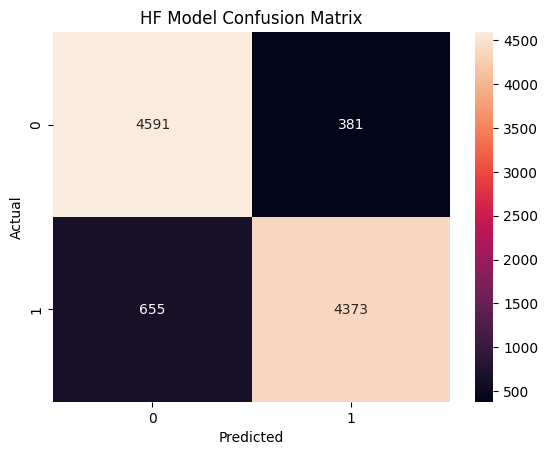

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_numeric, hf_preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("HF Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
hf_model.save_pretrained("sentiment_model")

In [34]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis", model="sentiment_model")

Device set to use mps:0


In [35]:
result = classifier("I think the movie was okayish, good for one time watch")

In [36]:
print(result)

[{'label': 'POSITIVE', 'score': 0.9991642236709595}]
